In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

tickers = [
    "AAPL", "MSFT", "GOOGL", "META", "AMZN", "NFLX", "TSLA", "ABNB",
    "NVDA", "AMD", "INTC", "QCOM", "AVGO", "MU", "ARM", "AMAT",
    "V", "MA", "PYPL", "COIN", "HOOD",
    "JPM", "GS", "BAC", "WFC", "MS", "BLK",
    "CRM", "NOW", "SNOW", "PLTR", "NET", "DDOG", "MDB",
    "WMT", "TGT", "COST", "EBAY", "SHOP",
    "UNH", "ISRG", "DXCM",
    "ENPH", "FSLR", "RIVN"
]
os.makedirs("data/eda", exist_ok=True)

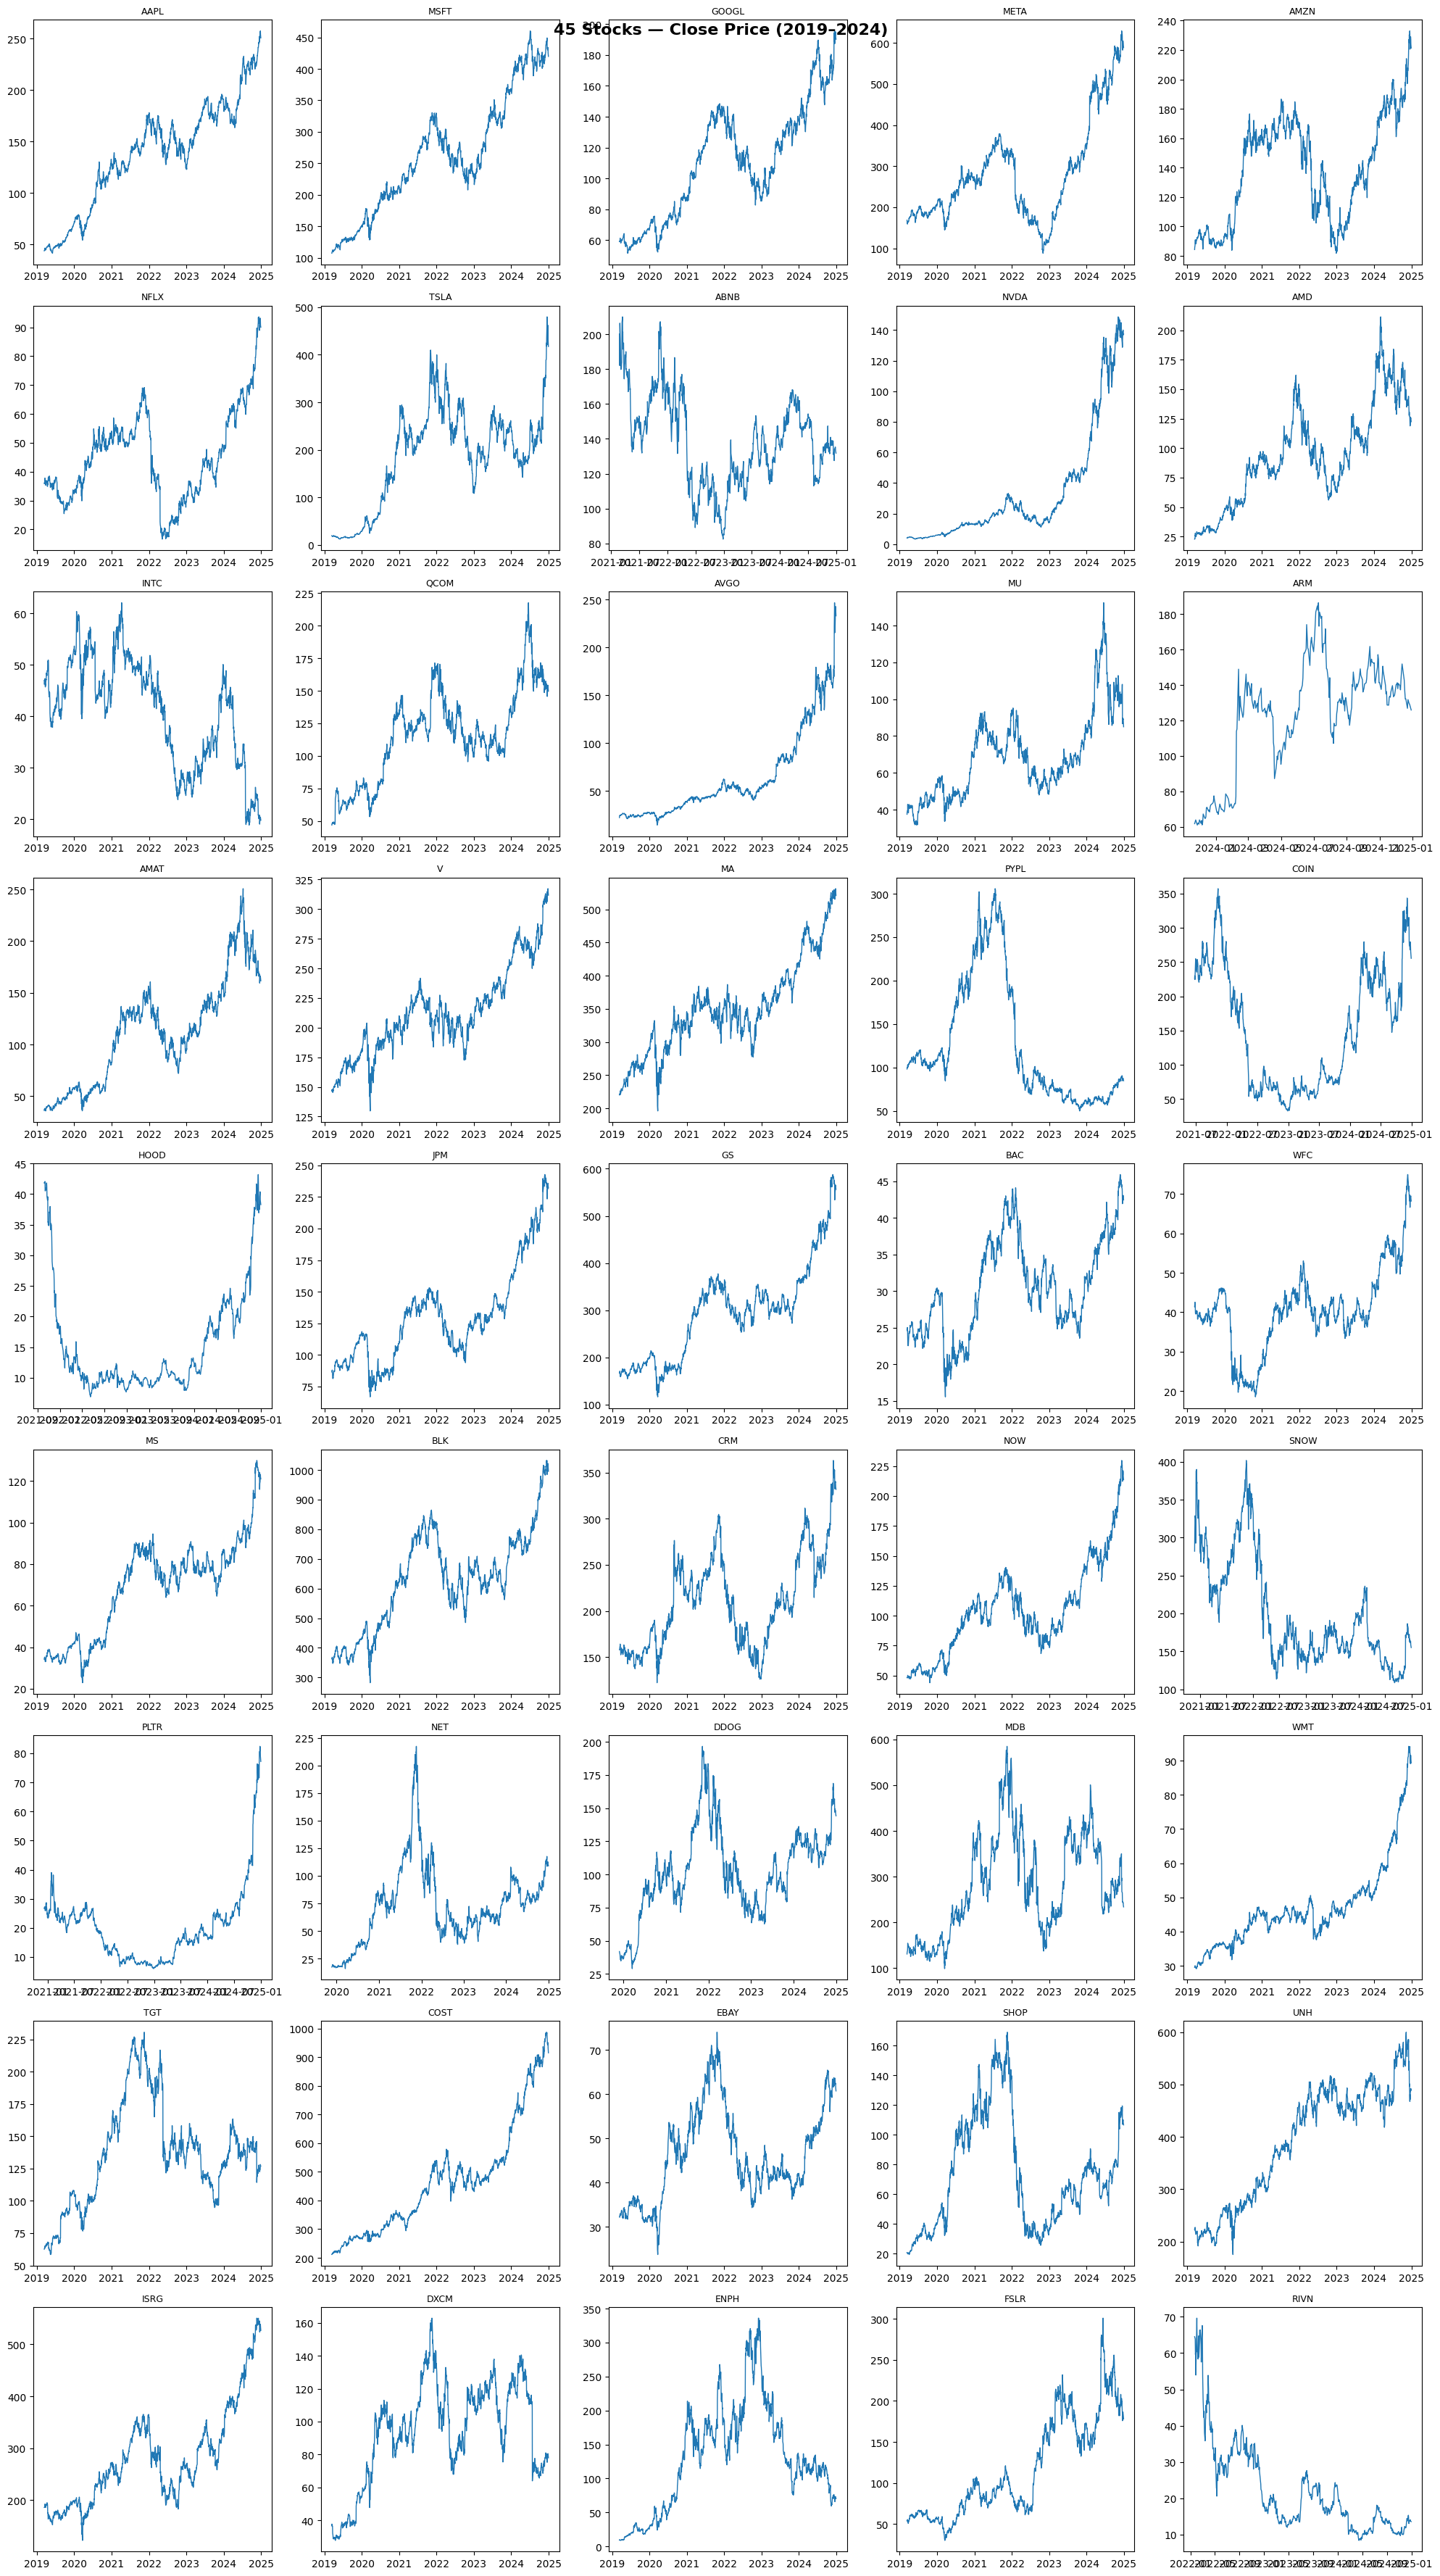

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math

n = len(tickers)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    try:
        df = pd.read_csv(
            f"data/features/{ticker}_features.csv",
            index_col=0,
            parse_dates=True
        )

        axes[i].plot(df.index, df["Close"], linewidth=1)
        axes[i].set_title(ticker, fontsize=9)

    except Exception as e:
        print(f"{ticker}: {e}")
        axes[i].set_title(f"{ticker} (error)", fontsize=8)

# 删除多余子图
for j in range(len(tickers), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    f"{len(tickers)} Stocks — Close Price (2019–2024)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("data/eda/all_stocks_price.png", dpi=150)
plt.show()

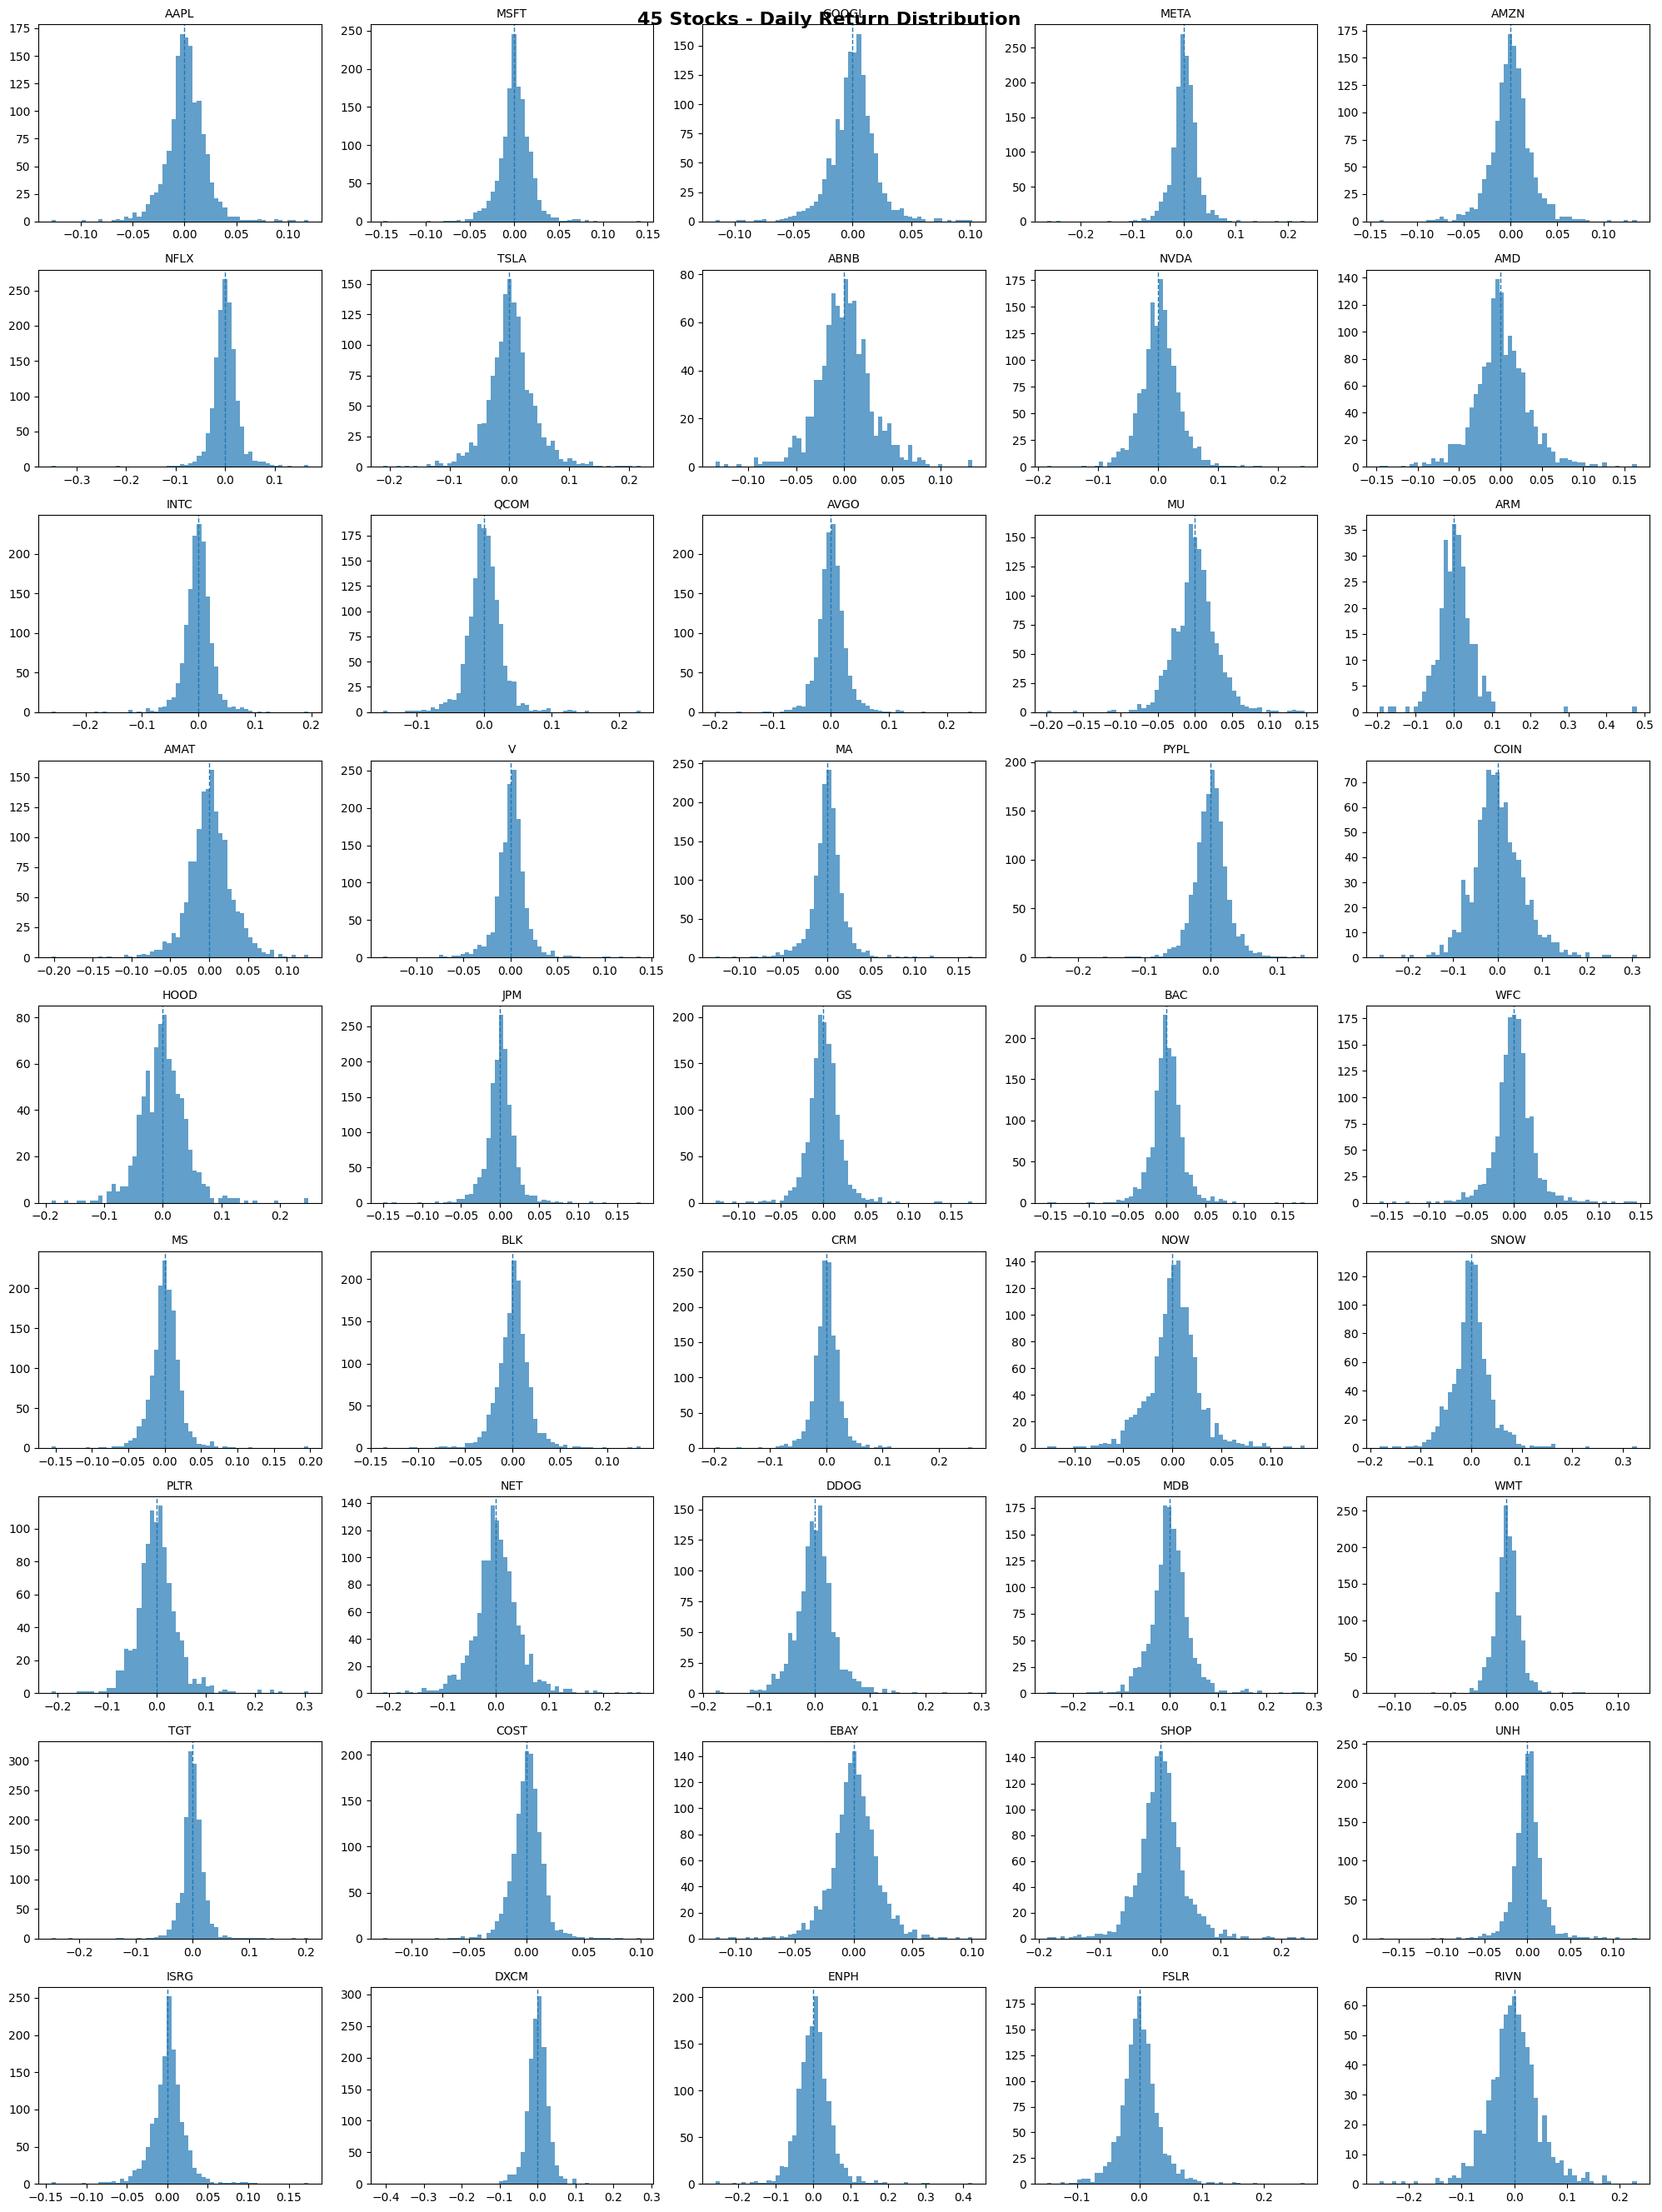

In [4]:
import math

n = len(tickers)

cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    df = pd.read_csv(
        f"data/features/{ticker}_features.csv",
        index_col=0,
        parse_dates=True
    )

    axes[i].hist(
        df["Return_1d"].dropna(),
        bins=60,
        edgecolor="none",
        alpha=0.7
    )

    axes[i].axvline(0, linestyle="--", linewidth=1)
    axes[i].set_title(ticker, fontsize=10)

# 删除空白子图
for j in range(len(tickers), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    f"{len(tickers)} Stocks - Daily Return Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("data/eda/return_distribution.png", dpi=150)
plt.show()

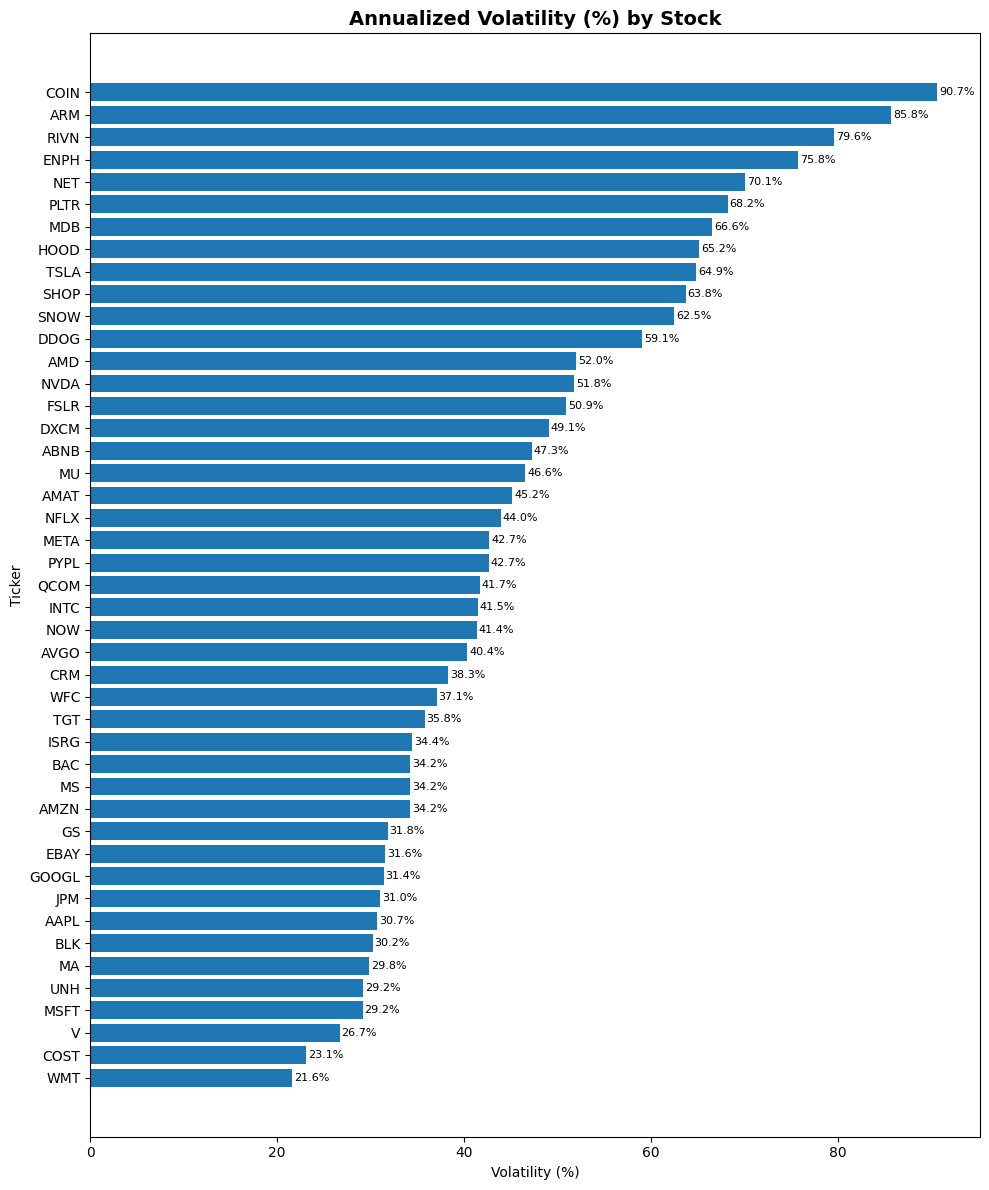


Annualized Volatility Ranking:
COIN     90.68
ARM      85.76
RIVN     79.59
ENPH     75.77
NET      70.07
PLTR     68.22
MDB      66.56
HOOD     65.18
TSLA     64.87
SHOP     63.76
SNOW     62.53
DDOG     59.06
AMD      51.98
NVDA     51.78
FSLR     50.92
DXCM     49.11
ABNB     47.29
MU       46.56
AMAT     45.19
NFLX     43.97
META     42.72
PYPL     42.66
QCOM     41.70
INTC     41.50
NOW      41.36
AVGO     40.38
CRM      38.30
WFC      37.09
TGT      35.78
ISRG     34.42
BAC      34.25
MS       34.21
AMZN     34.21
GS       31.83
EBAY     31.59
GOOGL    31.40
JPM      31.03
AAPL     30.70
BLK      30.23
MA       29.83
UNH      29.23
MSFT     29.15
V        26.68
COST     23.14
WMT      21.61
dtype: float64


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 计算年化波动率
volatility = {}

for ticker in tickers:
    try:
        df = pd.read_csv(
            f"data/features/{ticker}_features.csv",
            index_col=0
        )

        annual_vol = (
            df["Return_1d"]
            .dropna()
            .std()
            * np.sqrt(252)
            * 100
        )

        volatility[ticker] = annual_vol

    except Exception as e:
        print(f"{ticker}: {e}")

# 排序
vol_df = pd.Series(volatility).sort_values(ascending=False)

# 绘图
plt.figure(figsize=(10, 12))

bars = plt.barh(
    vol_df.index[::-1],
    vol_df.values[::-1]
)

plt.title(
    "Annualized Volatility (%) by Stock",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Volatility (%)")
plt.ylabel("Ticker")

# 显示数值标签
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "data/eda/volatility_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nAnnualized Volatility Ranking:")
print(vol_df.round(2))

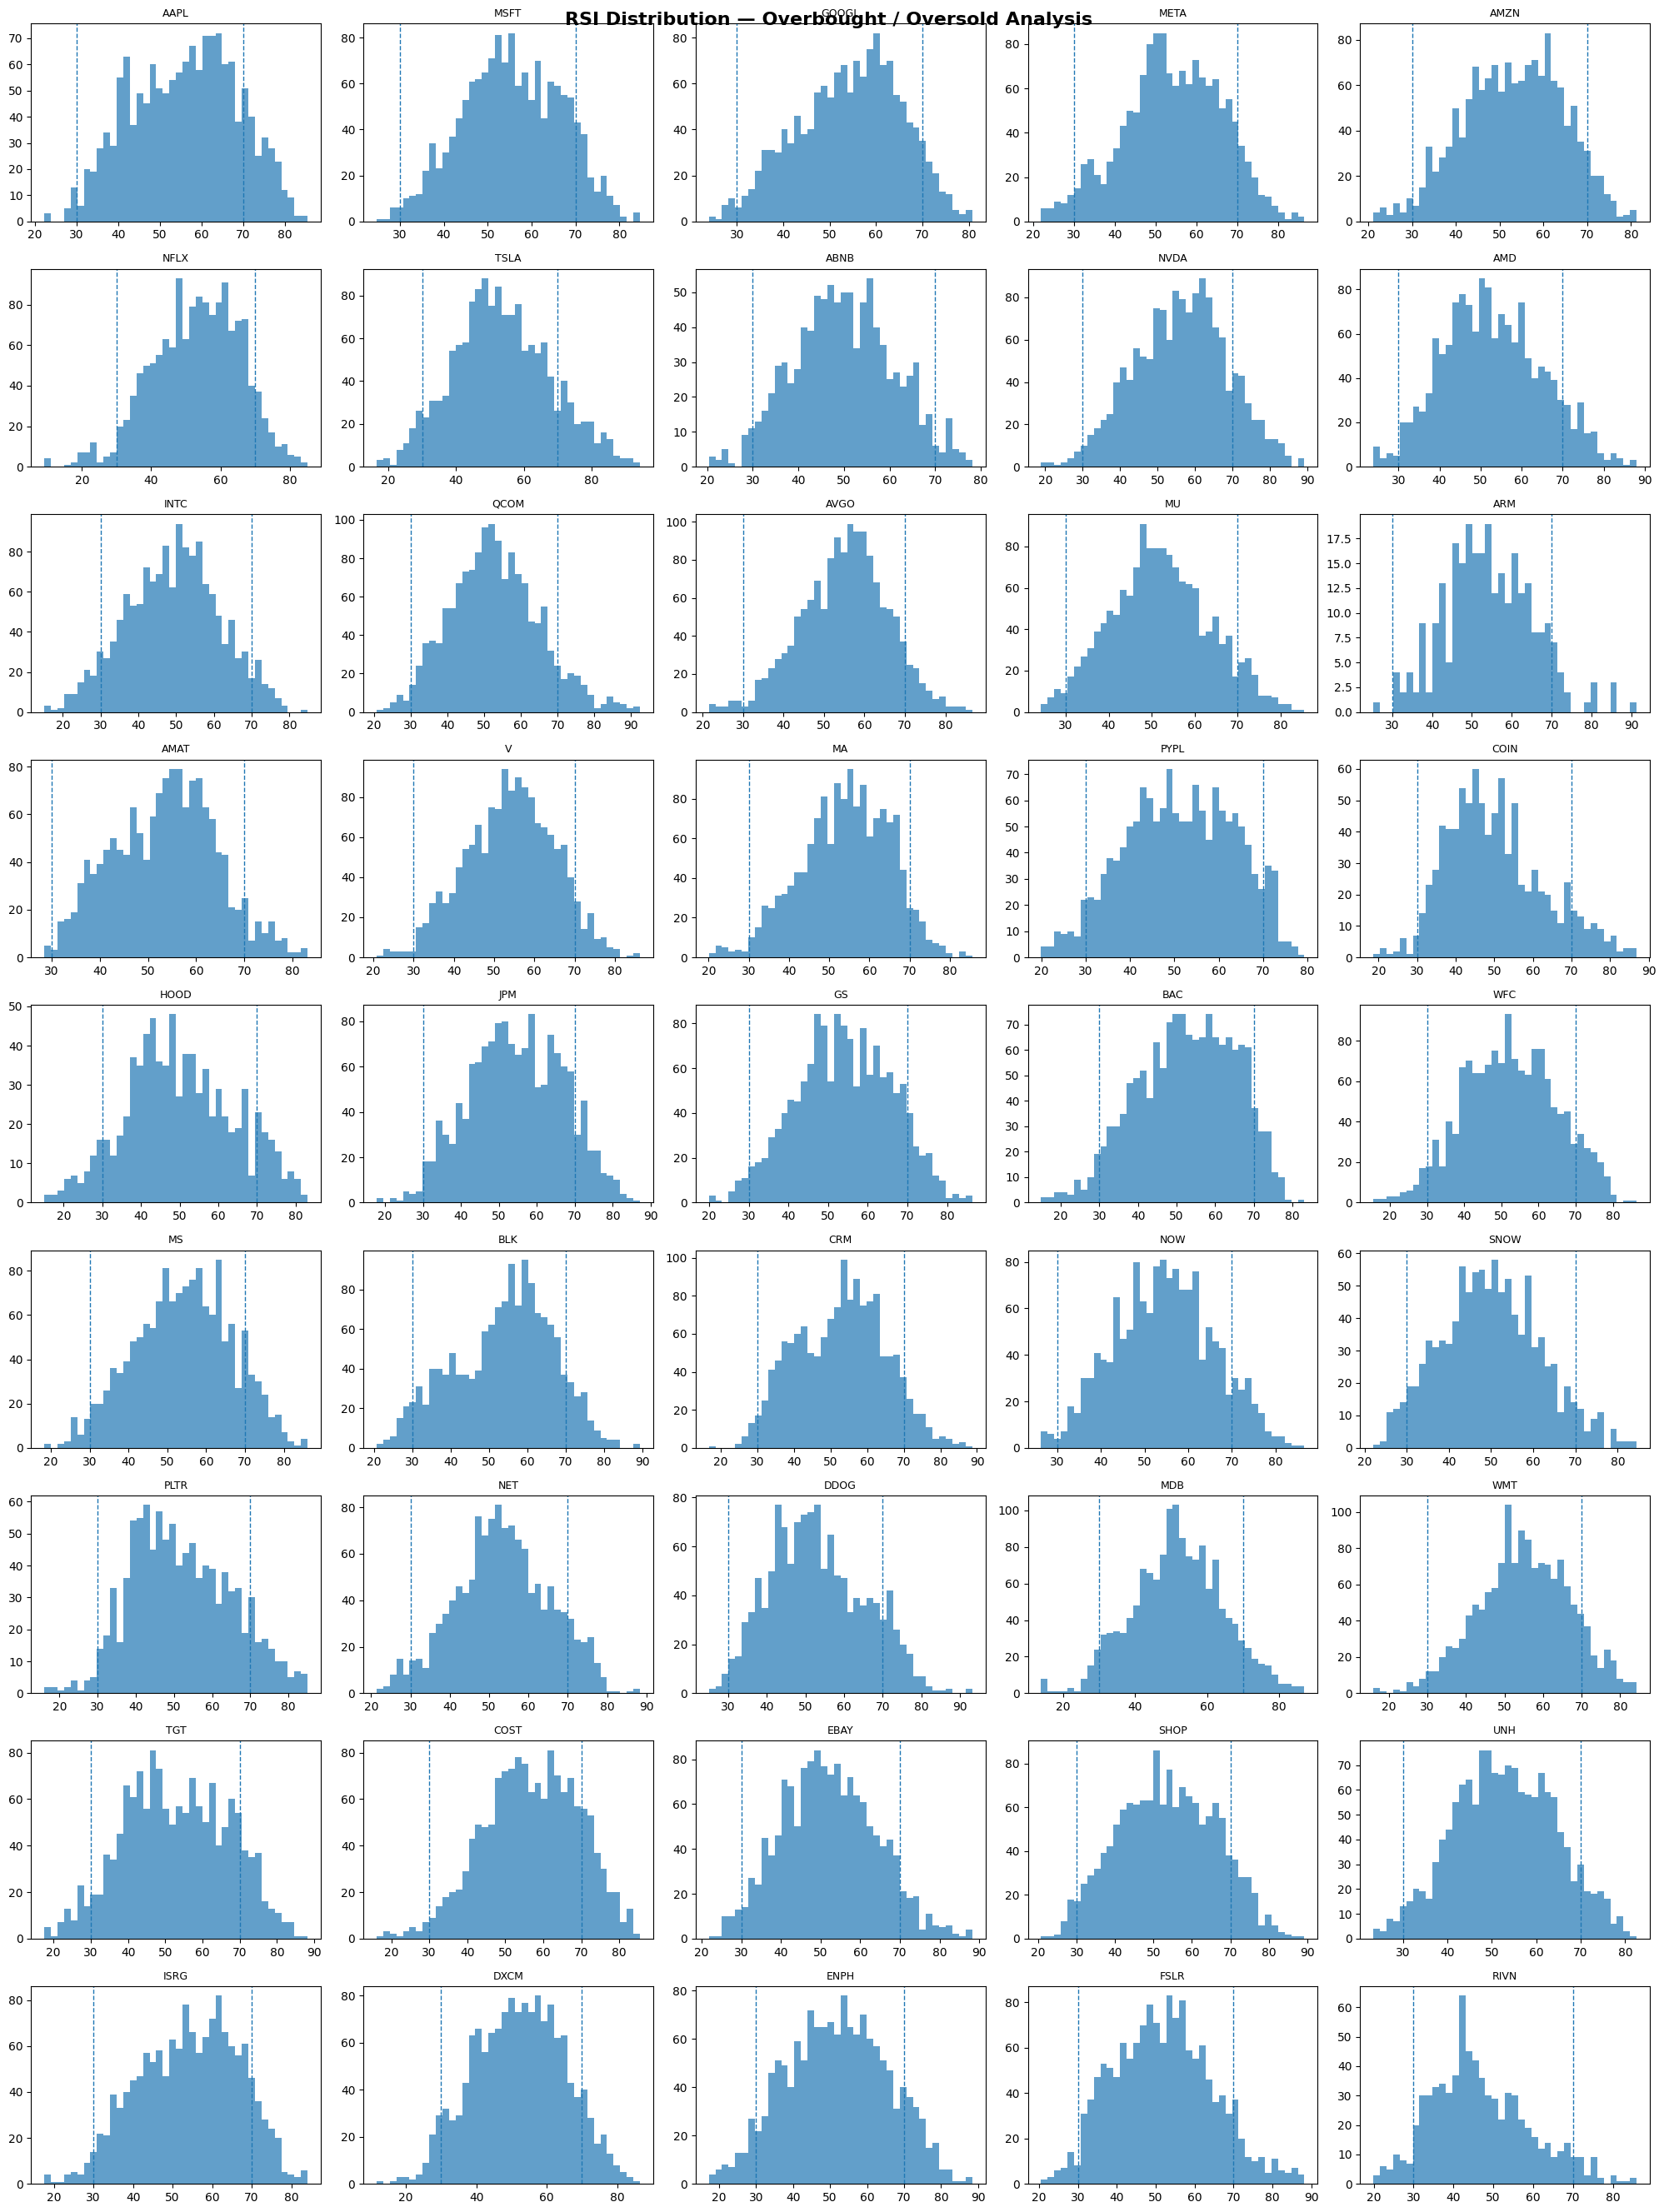

In [7]:
import math
import pandas as pd
import matplotlib.pyplot as plt

n = len(tickers)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(20, rows * 3)
)

axes = axes.flatten()

for i, ticker in enumerate(tickers):

    try:
        df = pd.read_csv(
            f"data/features/{ticker}_features.csv",
            index_col=0
        )

        axes[i].hist(
            df["RSI_14"].dropna(),
            bins=40,
            alpha=0.7
        )

        axes[i].axvline(
            70,
            linestyle="--",
            linewidth=1
        )

        axes[i].axvline(
            30,
            linestyle="--",
            linewidth=1
        )

        axes[i].set_title(
            ticker,
            fontsize=9
        )

    except Exception as e:
        print(f"{ticker}: {e}")

for j in range(len(tickers), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "RSI Distribution — Overbought / Oversold Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "data/eda/rsi_distribution.png",
    dpi=150
)

plt.show()

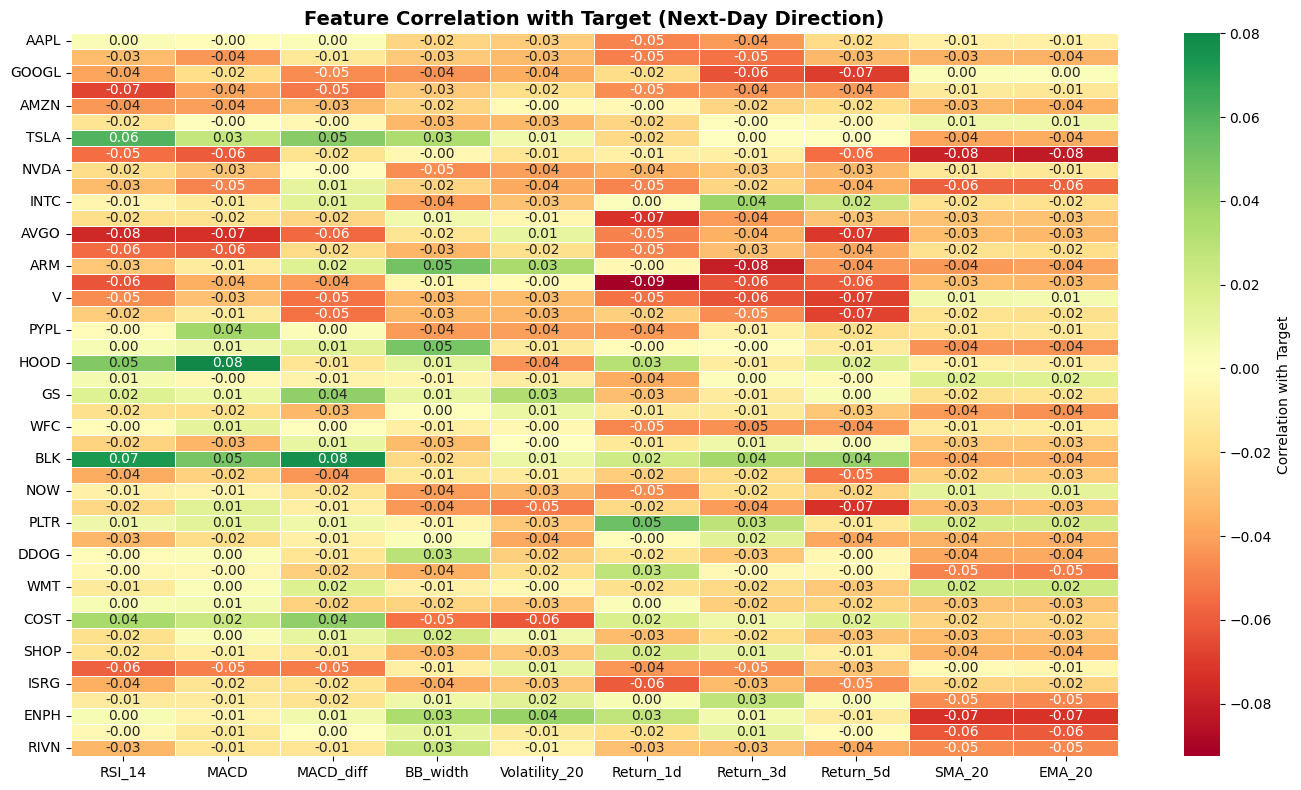

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = [
    "RSI_14",
    "MACD",
    "MACD_diff",
    "BB_width",
    "Volatility_20",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "SMA_20",
    "EMA_20"
]

corr_summary = {}

for ticker in tickers:

    try:
        df = pd.read_csv(
            f"data/features/{ticker}_features.csv",
            index_col=0
        )

        corr_summary[ticker] = (
            df[feature_cols]
            .corrwith(df["Target"])
        )

    except Exception as e:
        print(f"{ticker}: {e}")

corr_df = pd.DataFrame(corr_summary).T

plt.figure(figsize=(14, 8))

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={
        "label": "Correlation with Target"
    }
)

plt.title(
    "Feature Correlation with Target (Next-Day Direction)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "data/eda/feature_target_correlation.png",
    dpi=150
)

plt.show()

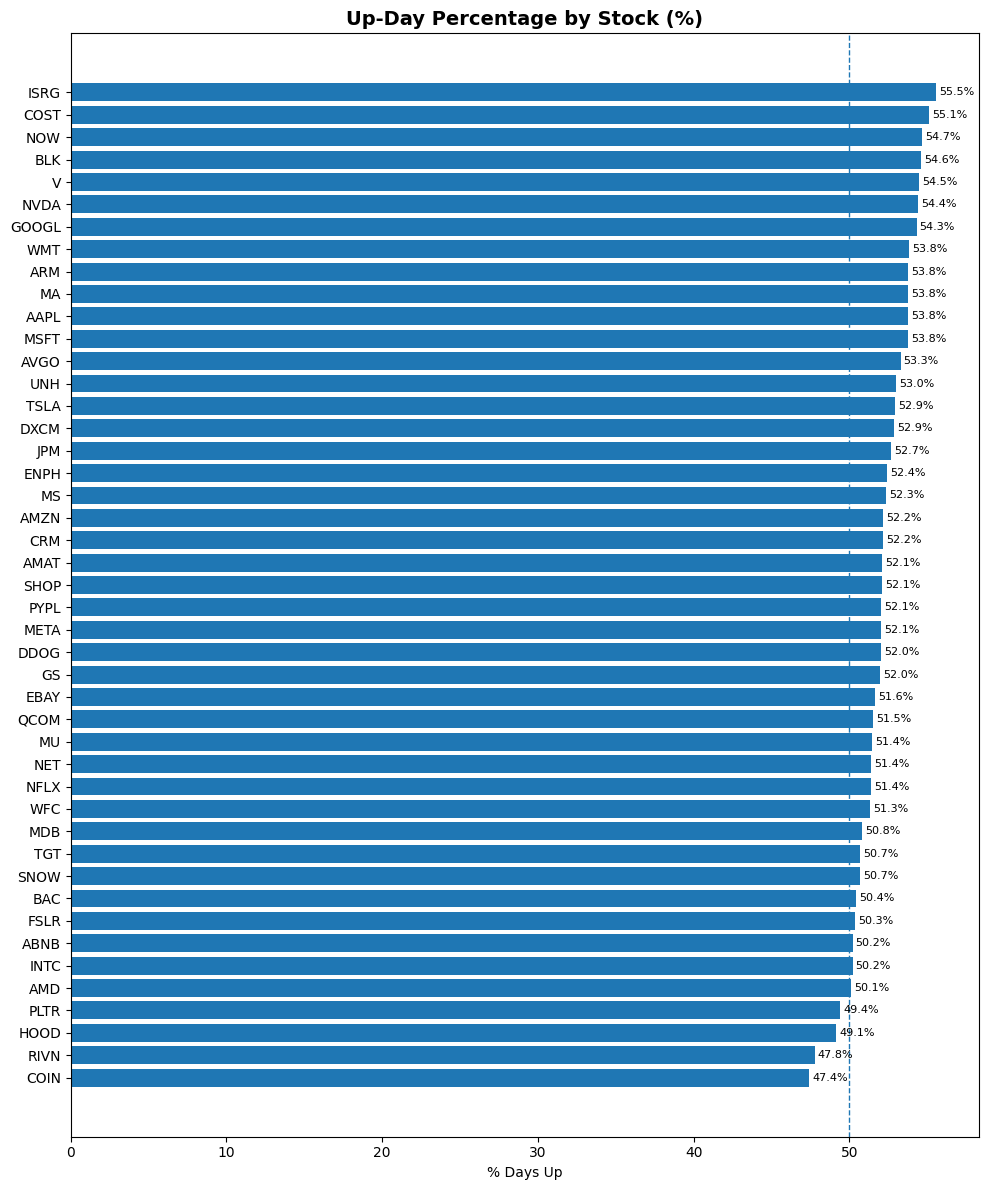

ISRG     55.55
COST     55.14
NOW      54.66
BLK      54.59
V        54.45
NVDA     54.38
GOOGL    54.32
WMT      53.84
ARM      53.79
MA       53.77
AAPL     53.77
MSFT     53.77
AVGO     53.29
UNH      53.01
TSLA     52.95
DXCM     52.88
JPM      52.67
ENPH     52.40
MS       52.33
AMZN     52.19
CRM      52.19
AMAT     52.12
SHOP     52.12
PYPL     52.05
META     52.05
DDOG     52.03
GS       51.99
EBAY     51.64
QCOM     51.51
MU       51.44
NET      51.40
NFLX     51.37
WFC      51.30
MDB      50.82
TGT      50.68
SNOW     50.68
BAC      50.41
FSLR     50.34
ABNB     50.21
INTC     50.21
AMD      50.14
PLTR     49.41
HOOD     49.14
RIVN     47.77
COIN     47.40
dtype: float64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

target_dist = {}

for ticker in tickers:

    try:
        df = pd.read_csv(
            f"data/features/{ticker}_features.csv",
            index_col=0
        )

        target_dist[ticker] = (
            df["Target"].mean() * 100
        )

    except Exception as e:
        print(f"{ticker}: {e}")

td = (
    pd.Series(target_dist)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 12))

bars = plt.barh(
    td.index[::-1],
    td.values[::-1]
)

plt.axvline(
    50,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Up-Day Percentage by Stock (%)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("% Days Up")

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "data/eda/target_distribution.png",
    dpi=150
)

plt.show()

print(td.round(2))

In [10]:
import numpy as np
import pandas as pd

summary = []

for ticker in tickers:

    try:

        df = pd.read_csv(
            f"data/features/{ticker}_features.csv",
            index_col=0
        )

        summary.append({

            "Ticker": ticker,

            "Samples":
                len(df),

            "Up_Day_%":
                round(
                    df["Target"].mean() * 100,
                    1
                ),

            "Annual_Volatility_%":
                round(
                    df["Return_1d"].std()
                    * np.sqrt(252)
                    * 100,
                    1
                ),

            "Mean_RSI":
                round(
                    df["RSI_14"].mean(),
                    1
                )
        })

    except Exception as e:
        print(f"{ticker}: {e}")

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(
    "Annual_Volatility_%",
    ascending=False
)

print(summary_df)

summary_df.to_csv(
    "data/eda/eda_summary.csv",
    index=False
)

   Ticker  Samples  Up_Day_%  Annual_Volatility_%  Mean_RSI
19   COIN      886      47.4                 90.7      50.2
14    ARM      277      53.8                 85.8      54.4
44   RIVN      739      47.8                 79.6      46.8
42   ENPH     1460      52.4                 75.8      52.0
31    NET     1284      51.4                 70.1      53.5
30   PLTR     1020      49.4                 68.2      52.1
33    MDB     1460      50.8                 66.6      51.9
20   HOOD      812      49.1                 65.2      50.2
6    TSLA     1460      52.9                 64.9      53.6
38   SHOP     1460      52.1                 63.8      53.6
29   SNOW     1030      50.7                 62.5      49.9
32   DDOG     1280      52.0                 59.1      53.1
9     AMD     1460      50.1                 52.0      53.0
8    NVDA     1460      54.4                 51.8      56.3
43   FSLR     1460      50.3                 50.9      51.9
41   DXCM     1460      52.9            